In [1]:
# Ek file banao with multiple selenium compounds
smiles_data = """SMILES,Name
C1=CC=CC=C1C(C[Se]C(C2=CC=CC=C2)=O)=O,UDS1b
c1ccc(cc1)[Se]c2ccccc2,DiphenylSelenide
C[Se]CCC(N)C(=O)O,Selenomethionine
c1ccc2c(c1)Cn(C2=O)[Se],Ebselen_like
O=C(N)[Se]c1ccccc1,SeAmide
[Se]=C(N)N,Selenourea"""

# File mein save karo
with open('selenium_compounds.csv', 'w') as f:
    f.write(smiles_data)
    
print("✅ File saved!")

✅ File saved!


In [2]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw

# File se data load karo
df = pd.read_csv('selenium_compounds.csv')
print("Loaded compounds:")
print(df)
print()

# Har compound ki properties calculate karo
results = []
for index, row in df.iterrows():
    mol = Chem.MolFromSmiles(row['SMILES'])
    if mol:  # agar molecule valid hai
        results.append({
            'Name': row['Name'],
            'SMILES': row['SMILES'],
            'MW': round(Descriptors.MolWt(mol), 2),
            'LogP': round(Descriptors.MolLogP(mol), 2),
            'TPSA': round(Descriptors.TPSA(mol), 2),
            'HBD': Descriptors.NumHDonors(mol),
            'HBA': Descriptors.NumHAcceptors(mol),
            'Rings': Descriptors.RingCount(mol)
        })

# Naya DataFrame banao
results_df = pd.DataFrame(results)
print("\nComplete Analysis Report:")
results_df

Loaded compounds:
                                  SMILES              Name
0  C1=CC=CC=C1C(C[Se]C(C2=CC=CC=C2)=O)=O             UDS1b
1                 c1ccc(cc1)[Se]c2ccccc2  DiphenylSelenide
2                      C[Se]CCC(N)C(=O)O  Selenomethionine
3                c1ccc2c(c1)Cn(C2=O)[Se]      Ebselen_like
4                     O=C(N)[Se]c1ccccc1           SeAmide
5                             [Se]=C(N)N        Selenourea


Complete Analysis Report:


,Name,SMILES,MW,LogP,TPSA,HBD,HBA,Rings
0,UDS1b,C1=CC=CC=C1C(C[Se]C(C2=CC=CC=C2)=O)=O,303.22,2.83,34.14,0,2,2
1,DiphenylSelenide,c1ccc(cc1)[Se]c2ccccc2,233.17,1.34,0.00,0,0,2
2,Selenomethionine,C[Se]CCC(N)C(=O)O,196.11,-0.04,63.32,2,2,0
3,Ebselen_like,c1ccc2c(c1)Cn(C2=O)[Se],211.10,0.73,20.31,0,1,2
4,SeAmide,O=C(N)[Se]c1ccccc1,200.10,0.09,43.09,1,1,1
5,Selenourea,[Se]=C(N)N,123.02,-1.84,52.04,2,2,0


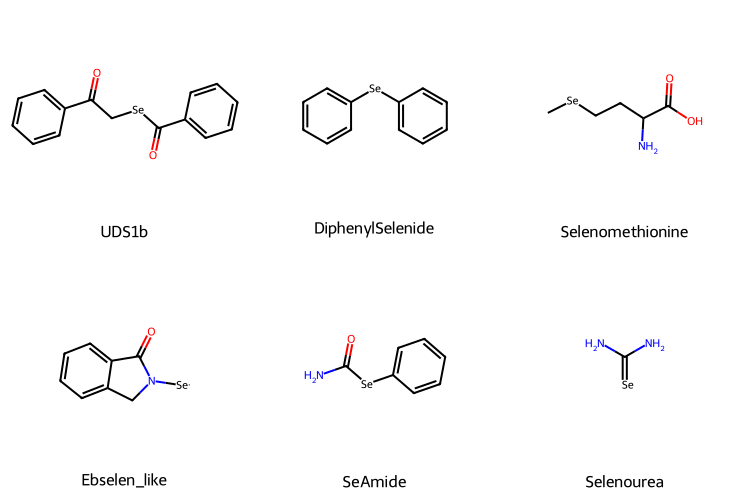

In [3]:
from rdkit import Chem
from rdkit.Chem import Draw

# Sab molecules banao
mols = []
names = []

for index, row in df.iterrows():
    mol = Chem.MolFromSmiles(row['SMILES'])
    if mol:
        mols.append(mol)
        names.append(row['Name'])

# Grid figure banao
img = Draw.MolsToGridImage(
    mols,
    molsPerRow=3,
    subImgSize=(250, 250),
    legends=names
)
img

In [4]:
# Drug-likeness filter
drug_like = results_df[
    (results_df['MW'] <= 500) &
    (results_df['LogP'] <= 5) &
    (results_df['HBD'] <= 5) &
    (results_df['HBA'] <= 10)
]

print(f"Total compounds: {len(results_df)}")
print(f"Drug-like compounds: {len(drug_like)}")
print()
print("Drug-like Selenium Compounds:")
drug_like

Total compounds: 6
Drug-like compounds: 6

Drug-like Selenium Compounds:


,Name,SMILES,MW,LogP,TPSA,HBD,HBA,Rings
0,UDS1b,C1=CC=CC=C1C(C[Se]C(C2=CC=CC=C2)=O)=O,303.22,2.83,34.14,0,2,2
1,DiphenylSelenide,c1ccc(cc1)[Se]c2ccccc2,233.17,1.34,0.00,0,0,2
2,Selenomethionine,C[Se]CCC(N)C(=O)O,196.11,-0.04,63.32,2,2,0
3,Ebselen_like,c1ccc2c(c1)Cn(C2=O)[Se],211.10,0.73,20.31,0,1,2
4,SeAmide,O=C(N)[Se]c1ccccc1,200.10,0.09,43.09,1,1,1
5,Selenourea,[Se]=C(N)N,123.02,-1.84,52.04,2,2,0


In [5]:
# MW ke hisaab se sort karo (chhote MW better for drugs)
sorted_df = results_df.sort_values('MW', ascending=True)
print("Sorted by Molecular Weight (lightest first):")
print(sorted_df[['Name', 'MW', 'LogP', 'TPSA']])

Sorted by Molecular Weight (lightest first):
               Name      MW  LogP   TPSA
5        Selenourea  123.02 -1.84  52.04
2  Selenomethionine  196.11 -0.04  63.32
4           SeAmide  200.10  0.09  43.09
3      Ebselen_like  211.10  0.73  20.31
1  DiphenylSelenide  233.17  1.34   0.00
0             UDS1b  303.22  2.83  34.14
